# DeepStream Pipeline
We will start with a simple DeepStream pipeline and then move towards a multi DNN pipeline.

We begin by using the `ffprobe` command line utility to understand the raw input video's format ([see documentation if needed](https://ffmpeg.org/ffprobe.html)). When using the `ffprobe` command, the `-i` option lets us read an input [URL](https://en.wikipedia.org/wiki/URL) and the `-hide_banner` option suppresses printing the banner to reduce the output. 

In [ ]:
import os

# Set the input video path to an environment variable
os.environ['TARGET_VIDEO_PATH']='data/sample_30.h264'
os.environ['TARGET_VIDEO_PATH_MP4']='sample_30.mp4'

target_video_path=os.environ['TARGET_VIDEO_PATH']
target_video_path_mp4=os.environ['TARGET_VIDEO_PATH_MP4']

# Analyze video
!ffprobe -i $TARGET_VIDEO_PATH \
         -hide_banner

Input #0, h264, from 'data/sample_30.h264':
  Duration: N/A, bitrate: N/A
    Stream #0:0: Video: h264 (High), yuv420p(progressive), 882x692, 30 fps, 30 tbr, 1200k tbn, 60 tbc


<video autoplay muted playsinline loop style="width: 100%; height: auto;">
  <source src="../../_static/sample_30.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

### TrafficCamNet Object Detection Model ###
The TrafficCamNet Object Detection model, according to its [model card](https://catalog.ngc.nvidia.com/orgs/nvidia/teams/tao/models/trafficcamnet), detects one or more physical objects from four categories (car, persons, road signs, and two-wheelers) _within an image_ and returns a box around each object, as well as a category label for each object. 

For example, given an input image/frame, the inference engine will generate the bounding box coordinates as well as the category labels: 

![image](../../_asset/nvidia/deepstream/images/sample_inference.png)

We can then _optionally_ perform post-processing and draw the bounding boxes and text labels on top of the original frame. 

![image](../../_asset/nvidia/deepstream/images/sample_bounding_boxes.png)

### Installing NGC CLI ###
Pre-trained models can be downloaded from NGC using the [NGC CLI](https://ngc.nvidia.com/setup/installers/cli).

To download a model from the registry, use the `ngc registry model download-version <org-name>/<model-name:version>` command and specify the model name as well as version. The model will be downloaded to a folder that corresponds to the model name in the current directory but can also be specified using the `-d` or `--dest` option. 

In [ ]:
!ngc registry model download-version nvidia/tao/trafficcamnet:pruned_v1.0 --dest $NGC_DIR

{
    "download_end": "2025-08-29 03:22:17",
    "download_start": "2025-08-29 03:22:15",
    "download_time": "1s",
    "files_downloaded": 3,
    "local_path": "/dli/task/ngc_assets/trafficcamnet_vpruned_v1.0",
    "size_downloaded": "5.2 MB",
    "status": "COMPLETED"
}


## Simple DeepStream Pipeline

This is the pipeline architecture of the application. We've selected each plugin based on their functionality. 

![image](../../_asset/nvidia/deepstream/images/deepstream_pipeline_pt1.png)

* The [filesrc](https://gstreamer.freedesktop.org/documentation/coreelements/filesrc.html) plugin reads data from a local file. There are other plugins available for reading data from various types of sources like camera, RTSP streams, and disk. 
* The [h264parse](https://gstreamer.freedesktop.org/documentation/videoparsersbad/h264parse.html) plugin is used to parse the input elementary H.264 stream into frame-size bytes of data. 
* The [nvv4l2decoder](https://gist.github.com/nins-k/6f7377629000894deedc7f14d7ef64fe) plugin decodes the input data using the appropriate codec, which is H.264 in this case.
* The [nvstreammux](https://docs.nvidia.com/metropolis/deepstream/dev-guide/text/DS_plugin_gst-nvstreammux.html) plugin is a required stream aggregator. This video aggregator helps in accepting `n` input streams and converts them into sequential batched frames. Even though our simple application only consumes one input stream, this plugin is required as `nvinfer` accepts _batched_ buffers with the `NvDsBatchMeta` structure already attached. 
    * This plugin takes `width`,  `height`, and `batch-size` as parameters. 
* The [nvinfer](https://docs.nvidia.com/metropolis/deepstream/dev-guide/text/DS_plugin_gst-nvinfer.html) plugin performs transformation (format conversion and scaling) on the input frame based on network requirements and passes the transformed data to the low-level library. This is the plugin that we will use to define the deep learning task(s) associated with our application. The low-level library pre-processes the transformed frames (performs normalization and mean subtraction) and produces final float RGB/BGR/GRAY planar data which are passed to the TensorRT engine for inferencing. The output type generated by the low-level library depends on the network type. We will configure the `nvinfer` plugin for our `TrafficCamNet` object detection model. It attaches the inference results such as _object class(s)_, _bounding box coordinates_, _etc._, to the metadata.

![image](../../_asset/nvidia/deepstream/images/nvinfer.png)

* The [fakesink](https://gstreamer.freedesktop.org/documentation/coreelements/fakesink.html) plugin acts as the end of the pipeline where the data flow ends. 
    * There is a synchronization-against-the-clock mechanism in GStreamer. For local video file, it is recommended to set the `sync` property to `1` to get smooth video playback, vs. `0` for live-sources such as IP camera since they give frames at a static rate. 

*More information about the plugins can be found in the [DeepStream Plugin Guide](https://docs.nvidia.com/metropolis/deepstream/dev-guide/index.html#plugins-development-guide) and [GStreamer Plugin Guide](https://gstreamer.freedesktop.org/documentation/plugins_doc.html).*

Additionally, we will add a **callback function** on the source pad of the `nvinfer` plugin to access the metadata in the application. The application can then use this metadata to solve the given problem (in this case counting the number of cars, persons, road signs, and two-wheelers).

### Initializing GStreamer and Pipeline ###
We initialize GStreamer with `Gst.init(list=None)` and instantiate a `Gst.Pipeline` object as `pipeline` to contain all the elements shown in the pipeline diagram. 

In [ ]:
# Import necessary GStreamer libraries and DeepStream python bindings
import gi
gi.require_version('Gst', '1.0')
from gi.repository import GObject, Gst, GLib
import pyds

# Initialize GStreamer
Gst.init(None)

# Create Pipeline element that will form a connection of other elements
pipeline=Gst.Pipeline()
print('Created pipeline')

Created pipeline


### Creating Pipeline Elements ###
We create each element in the pipeline using `Gst.ElementFactory.make(factoryname, name)` (see [documentation](https://lazka.github.io/pgi-docs/Gst-1.0/classes/ElementFactory.html#Gst.ElementFactory.make)). We can configure elements using `set_property(property_name, value)` (see [documentation](https://gstreamer.freedesktop.org/documentation/plugin-development/basics/args.html?gi-language=c)) with the required parameters as needed. In this step, we also add the elements to the pipeline with `Gst.Pipeline.add(element)`. 

In [ ]:
# Create Source element for reading from a file and set the location property
source=Gst.ElementFactory.make("filesrc", "file-source")
source.set_property('location', target_video_path)

# Create H264 Parser with h264parse as the input file is an elementary h264 stream
h264parser=Gst.ElementFactory.make("h264parse", "h264-parser")

# Create Decoder with nvv4l2decoder for accelerated decoding on GPU
decoder=Gst.ElementFactory.make("nvv4l2decoder", "nvv4l2-decoder")

# Create Streamux with nvstreammux to form batches for one or more sources and set properties
streammux=Gst.ElementFactory.make("nvstreammux", "stream-muxer")
streammux.set_property('width', 888) 
streammux.set_property('height', 696) 
streammux.set_property('batch-size', 1)

# Create Primary GStreamer Inference Element with nvinfer to run inference on the decoder's output after batching
pgie=Gst.ElementFactory.make("nvinfer", "primary-inference")

# Create Sink with fakesink as the end point of the pipeline
fakesink=Gst.ElementFactory.make('fakesink', 'fakesink')
fakesink.set_property('sync', 1)
print('Created elements')

Created elements


In [ ]:
# Add elements to pipeline
pipeline.add(source)
pipeline.add(h264parser)
pipeline.add(decoder)
pipeline.add(streammux)
pipeline.add(pgie)
pipeline.add(fakesink)
print('Added elements to pipeline')

Added elements to pipeline


#### Explore Gst-nvinfer Configuration File ####
The `nvinfer` plugin needs to be configured through a `config file`

These properties are important to understand: 
* Properties related to models downloaded from NGC or trained with the TAO Toolkit: 
    * `tlt-encoded-model` - pathname of the TAO Toolkit encoded model
    * `tlt-model-key` - model load key for the TAO Toolkit encoded model
    * `labelfile-path` - pathname of a text file containing the labels for the model. The labels must be new line delimited for object detection models
    * `uff-input-blob-name` - name of the input blob in the UFF file
    * `output-blob-names` - array of output layer names
    * `infer-dims` - dimensions of the model input as [channel; height; width]
    * `net-scale-factor` - pixel normalization factor _(default=1)_

* Recommended properties: 
    * `batch-size` - number of frames to be inferred together in a batch _(default=1)_

* Mandatory properties for detectors: 
    * `num-detected-classes` - number of classes detected by the network

* Optional properties for detectors: 
    * `cluster-mode` - clustering algorithm to use _(default=0 i.e. Group Rectangles)_. Refer to the section on [clustering algorithms supported by nvinfer](https://docs.nvidia.com/metropolis/deepstream/dev-guide/text/DS_plugin_gst-nvinfer.html#cluster-mode-info) in the documentation for more information. 
    * `nms-iou-thresholds`: maximum IOU score between two proposals after which the proposal with the lower confidence will be rejected
    * `pre-cluster-thresholds`: detection threshold to be applied prior to clustering
    * `topk`: keep only top K objects with highest detection scores

* Other optional properties: 
    * `network-mode` - data format to be used for inference _(0=FP32, 1=INT8, 2=FP16 mode | default=0 i.e. FP32)_
    * `process-mode` - mode _(primary or secondary)_ in which the plugin is to operate on _(default=1 i.e. primary)_
    * `model-color-format` - color format required by the model _(default=0 i.e. RGB)_
    * `interval` - number of consecutive batches to be skipped for inference _(primary mode only | default=0)_
    * `gie-unique-id` - unique ID to be assigned to the GIE to enable the application and other elements to identify detected bounding boxes and labels _(default=0)_
    * `gpu-id` - device ID of GPU to use for pre-processing/inference _(dGPU only)_

You can find most of the information needed on the [model card](https://catalog.ngc.nvidia.com/orgs/nvidia/teams/tao/models/trafficcamnet): 

![image](../../_asset/nvidia/deepstream/images/encryption_key.png)
![image](../../_asset/nvidia/deepstream/images/model_card.png)

![image](../../_asset/nvidia/deepstream/images/blob_names.png)

In [ ]:
!cat spec_files/pgie_config_trafficcamnet_03.txt

[property]
gpu-id=0
net-scale-factor=0.00392156862745098
tlt-model-key=tlt_encode
tlt-encoded-model=/dli/task/ngc_assets/trafficcamnet_vpruned_v1.0/resnet18_trafficcamnet_pruned.etlt
labelfile-path=/dli/task/ngc_assets/trafficcamnet_vpruned_v1.0/labels.txt
infer-dims=3;544;960
uff-input-blob-name=input_1
batch-size=1
process-mode=1
model-color-format=0
# 0=FP32, 1=INT8, 2=FP16 mode
network-mode=0
num-detected-classes=4
interval=0
gie-unique-id=1
output-blob-names=output_bbox/BiasAdd;output_cov/Sigmoid
cluster-mode=2

# Use the config params below for NMS clustering mode
[class-attrs-all]
topk=20
nms-iou-threshold=0.5
pre-cluster-threshold=0.2

**Note**: The values in the config file can be overridden by values set through `GObject` properties. Another important thing to remember is that the properties recommended are specific to a primary detector. You may need to configure other properties for secondary and/or classifier. 

After the configuration file has been created, we set the configuration file path of the `nvinfer` plugin using `set_property(property_name, value)`. 

In [ ]:
# Set the configuration-file-path property for nvinfer
pgie.set_property('config-file-path', '/dli/task/spec_files/pgie_config_trafficcamnet_03.txt')

### Linking Pipeline Elements ###
Finally, we link all these elements in the order that data flow through the pipeline with `Gst.Element.link(Gst.Element)`.

In GStreamer, elements are connected through pads:
- Static pads: Always available.
- Request pads: Created on-demand; you need to "request" one explicitly.

You can find the inforamtion of the pad using
`gst-inspect-1.0 <element-name>`

```yaml
Pad Templates:
  SRC template: 'src'
    Availability: Always
    ...
  SINK template: 'sink_%u'
    Availability: Request
    ...
```
In DeepStream pipelines, nvstreammux (streammux) requires a separate input pad per input stream, like `sink_0`, `sink_1` etc... Or in other words-- when connecting a source to `nvstreammux` (the muxer), the input's source pad, obtained from `get_static_pad(name='src')`, must be manually linked to a newly requested sink pad from the muxer using `get_request_pad(name)` and the pad template `sink_%u`. This enables the ability to have multiple sources feeding into the `nvstreammux` plugin. 

In [16]:
# Finding pad information using python
from gi.repository import Gst

factory = Gst.ElementFactory.find("nvstreammux")
pad_templates = factory.get_static_pad_templates()

for pad_template in pad_templates:
    direction = "SRC" if pad_template.direction == Gst.PadDirection.SRC else "SINK"
    availability = pad_template.presence.value_nick
    name_template = pad_template.name_template
    print(f"{direction} pad: {name_template} ({availability})")

SINK pad: sink_%u (request)
SRC pad: src (always)


#### Linking the pipeline

In [ ]:
# Link elements in the pipeline
source.link(h264parser)
h264parser.link(decoder)

# Link decoder source pad to streammux sink pad
decoder_srcpad=decoder.get_static_pad("src")    
streammux_sinkpad=streammux.get_request_pad("sink_0")
decoder_srcpad.link(streammux_sinkpad)

# Link the rest of the elements in the pipeline
streammux.link(pgie)
pgie.link(fakesink)
print('Linked elements in pipeline')

Linked elements in pipeline


### Probe to Metadata Access ###
Recall that we use probes to access metadata, which are callback functions that interact with the pads of elements. To access the metadata, we can use the DeepStream Python bindings, `pyds`. DeepStream uses an extensible standard structure for metadata. The basic metadata structure `NvDsBatchMeta` starts with batch-level metadata, created inside the `Gst-nvstreammux` plugin (see below). The object-level metadata we are looking for is accessible through `NvDsBatchMeta` > `NvDsFrameMeta` > `NvDsObjectMeta`. Some metadata instances are stored in `GList` form, which requires the data to be casted to the appropriate structure using `pyds.NvDsFrameMeta.cast(data)` or  `pyds.NvDsObjectMeta.cast(data)`. The `NvDsObjectMeta` contains the inference results from the deep learning neural networks, depending on what the configurations are. 

![image](../../_asset/nvidia/deepstream/images/DS_plugin_metadata.png)

We write the user-defined callback function `pgie_source_pad_buffer_probe`. Inside the function, we first get the batch metadata from the buffer with `pyds.gst_buffer_get_nvds_batch_meta`. From there, we can iterate through all the metadata types that are attached to the buffer. The DeepStream plugins attach metadata of type `NVDS_META_FRAME_INFO` to the buffer. To achieve our goal, we access the object metadata to count the number of objects in each frame and print the bounding box coordindates. In this example we are using a 4-class-detectors (vehicle, person, two-wheeler, and road sign). The return value of the probe function is programmed to `Gst.PadProbeReturn.OK`, which is the normal probe return value and leaves the probe in place. There are other options for the [return value](https://lazka.github.io/pgi-docs/Gst-1.0/enums.html#Gst.PadProbeReturn) that can be considered for more complex cases. 

In [ ]:
# Declare list to hold count data
obj_counts=[]

# Define the Probe Function
def pgie_src_pad_buffer_probe(pad, info):
    gst_buffer=info.get_buffer()

    # Retrieve batch metadata from the gst_buffer
    # Note that pyds.gst_buffer_get_nvds_batch_meta() expects the
    # C address of gst_buffer as input, which is obtained with hash(gst_buffer)
    batch_meta=pyds.gst_buffer_get_nvds_batch_meta(hash(gst_buffer))
    l_frame=batch_meta.frame_meta_list
    
    # Iterate through each frame in the batch metadata until the end
    while l_frame is not None:
        try:
            frame_meta=pyds.NvDsFrameMeta.cast(l_frame.data)
        except StopIteration:
            break

        frame_num=frame_meta.frame_num
        num_obj=frame_meta.num_obj_meta
        l_obj=frame_meta.obj_meta_list
        
        print("Frame Number={} Number of Objects={}".format(frame_num, num_obj))
        
        # Append number of objects a list 
        obj_counts.append(num_obj)
        
        # Iterate through each object in the frame metadata until the end
        while l_obj is not None:
            try:
                obj_meta=pyds.NvDsObjectMeta.cast(l_obj.data)
                print('\t Object: {} - Top: {}, Left: {}, Width: {}, Height: {}'.format(obj_meta.obj_label, \
                                                                round(obj_meta.rect_params.top), \
                                                                round(obj_meta.rect_params.left), \
                                                                round(obj_meta.rect_params.width), \
                                                                round(obj_meta.rect_params.height)))
            except StopIteration:
                break
            
            try: 
                l_obj=l_obj.next
            except StopIteration:
                break
        
        try:
            l_frame=l_frame.next
        except StopIteration:
            break
    return Gst.PadProbeReturn.OK

With the pipeline defined and the elements linked, we add the callback function on the source pad of the `nvinfer` plugin using `Gst.Pad.add_probe(mask, callback)`. While attached, the probe notifies when there are data passing on a pad. We can use `GST_PAD_PROBE_TYPE_BUFFER` or `GST_PAD_PROBE_TYPE_BUFFER_LIST` for `mask` when creating the probe. We designed the callback function to work with a single buffer so we're using `Gst.PadProbeType.BUFFER`. 

In [ ]:
# Add probe to inference plugin's source
pgie_src_pad=pgie.get_static_pad('src')
probe_id=pgie_src_pad.add_probe(Gst.PadProbeType.BUFFER, pgie_src_pad_buffer_probe)
print('Attached probe')

Attached probe


### Starting the Pipeline ###
The pipeline has a bus that we will use to monitor messages. We run a GLib/Gtk+ `MainLoop` (or iterate the default GLib main context regularly) and attach a watch/message handler to the bus with `Gst.Bus.add_signal_watch()`. This way the `GLib.Mainloop` will check the bus for new messages and notify. The message handler is also achieved through a callback function, which we define as `bus_call`. This handler will be called whenever the pipeline emits a message to the bus. The return value of the callback function should be `True` to keep it attached to the bus. With the message handler in place, we put the pipeline in the `PLAYING` state and run the `MainLoop`. Finally, when the pipeline is finished, we put the pipeline into the `NULL` state to clean up.

In [ ]:
import gi
import sys
gi.require_version('Gst', '1.0')
from gi.repository import GObject, Gst
def bus_call(bus, message, loop):
    t = message.type
    if t == Gst.MessageType.EOS:
        sys.stdout.write("End-of-stream")
        loop.quit()
    elif t==Gst.MessageType.WARNING:
        err, debug = message.parse_warning()
        sys.stderr.write("Warning: %s: %s\n" % (err, debug))
    elif t == Gst.MessageType.ERROR:
        err, debug = message.parse_error()
        sys.stderr.write("Error: %s: %s\n" % (err, debug))
        loop.quit()
    return True

In [ ]:
# Create an event loop
loop=GLib.MainLoop()

# Feed GStreamer bus messages to loop
bus=pipeline.get_bus()
bus.add_signal_watch()
bus.connect("message", bus_call, loop)
print('Added bus message handler')

Added bus message handler


In [ ]:
# Start play back and listen to events
print("Starting pipeline")
pipeline.set_state(Gst.State.PLAYING)
try:
    loop.run()
except:
    pass

# Cleaning up as the pipeline comes to an end
pipeline.set_state(Gst.State.NULL)

Starting pipeline


0:28:08.735014002   436      0x2ac5920 INFO                 nvinfer gstnvinfer.cpp:682:gst_nvinfer_logger:<primary-inference> NvDsInferContext[UID 1]: Info from NvDsInferContextImpl::buildModel() <nvdsinfer_context_impl.cpp:2002> [UID = 1]: Trying to create engine from model files
ERROR: [TRT]: 3: [builder.cpp::~Builder::307] Error Code 3: API Usage Error (Parameter check failed at: optimizer/api/builder.cpp::~Builder::307, condition: mObjectCounter.use_count() == 1. Destroying a builder object before destroying objects it created leads to undefined behavior.
)
0:28:31.241559380   436      0x2ac5920 INFO                 nvinfer gstnvinfer.cpp:682:gst_nvinfer_logger:<primary-inference> NvDsInferContext[UID 1]: Info from NvDsInferContextImpl::buildModel() <nvdsinfer_context_impl.cpp:2034> [UID = 1]: serialize cuda engine to file: /dli/task/ngc_assets/trafficcamnet_vpruned_v1.0/resnet18_trafficcamnet_pruned.etlt_b1_gpu0_fp32.engine successfully
0:28:31.309896234   436      0x2ac5920 INFO 

Frame Number=0 Number of Objects=1
	 Object: car - Top: 26, Left: 366, Width: 59, Height: 37
Frame Number=1 Number of Objects=1
	 Object: car - Top: 26, Left: 366, Width: 60, Height: 37
Frame Number=2 Number of Objects=1
	 Object: car - Top: 26, Left: 366, Width: 60, Height: 37
Frame Number=3 Number of Objects=1
	 Object: car - Top: 26, Left: 367, Width: 62, Height: 41
Frame Number=4 Number of Objects=1
	 Object: car - Top: 26, Left: 367, Width: 62, Height: 41
Frame Number=5 Number of Objects=1
	 Object: car - Top: 26, Left: 367, Width: 63, Height: 41
Frame Number=6 Number of Objects=1
	 Object: car - Top: 28, Left: 369, Width: 65, Height: 40
Frame Number=7 Number of Objects=1
	 Object: car - Top: 28, Left: 368, Width: 66, Height: 41
Frame Number=8 Number of Objects=1
	 Object: car - Top: 28, Left: 369, Width: 66, Height: 40
Frame Number=9 Number of Objects=1
	 Object: car - Top: 29, Left: 369, Width: 74, Height: 50
Frame Number=10 Number of Objects=1
	 Object: car - Top: 29, Left: 369

<enum GST_STATE_CHANGE_SUCCESS of type Gst.StateChangeReturn>

### Analyzing Inference Results ###
After the DeepStream pipeline completes the video processing, we summarize the inference results. 

<AxesSubplot: title={'center': 'Object Count Over Time'}, xlabel='Frame Number'>

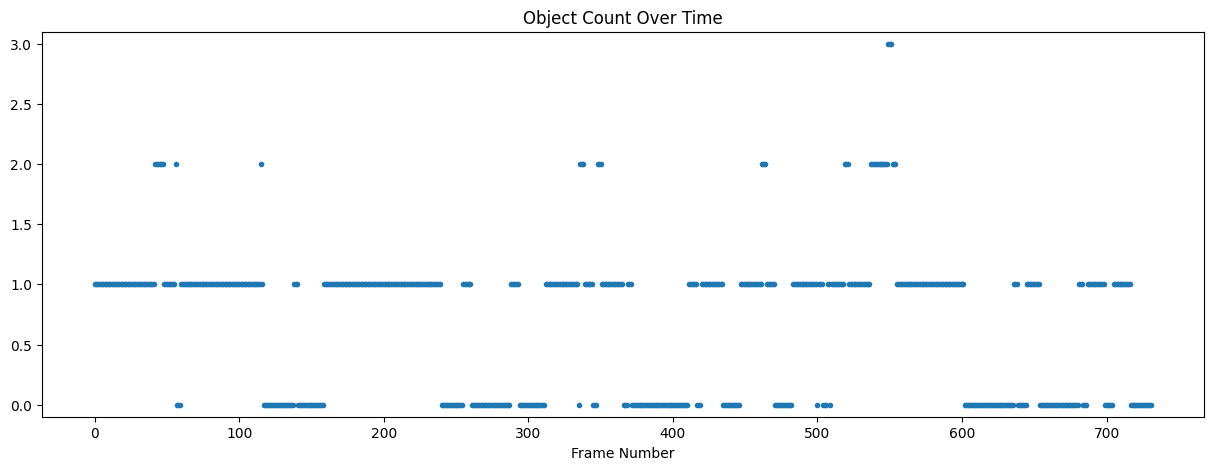

In [ ]:
import pandas as pd

# Export data to a Pandas Series
obj_count_df=pd.Series(obj_counts, name='Object Count')
obj_count_df.index.name='Frame Number'

# Plot the Series
obj_count_df.plot(
    linestyle='none', 
    marker='.', 
    figsize=(15, 5), 
    ylim=[-.1, 3.1], 
    title='Object Count Over Time'
)

### Extending the Pipeline ###
We will add additional functionalities to the DeepStream pipeline to also create a composite video and write the output to a file. This is the updated pipeline architecture. We've adding new plugins based on their functionality. 

![image](../../_asset/nvidia/deepstream/images/deepstream_pipeline.png)

* The [filesrc](https://gstreamer.freedesktop.org/documentation/coreelements/filesrc.html) plugin will read data from a local file. There are other plugins available for reading data from various types of sources like camera, RTSP streams, and disk. 
* The [h264parse](https://gstreamer.freedesktop.org/documentation/videoparsersbad/h264parse.html) plugin is used to parse the input elementary H.264 stream into frame-size bytes of data. 
* The [nvv4l2decoder](https://gist.github.com/nins-k/6f7377629000894deedc7f14d7ef64fe) plugin will decode the input data using the appropriate codec, which is H.264 in this case.
* The [nvstreammux](https://docs.nvidia.com/metropolis/deepstream/dev-guide/text/DS_plugin_gst-nvstreammux.html) plugin is a required stream aggregator. This video aggregator helps in accepting `n` input streams and converts them into sequential batched frames. Even though our simple application only consumes one input stream, this plugin is required as `nvinfer` accepts _batched_ buffers with the `NvDsBatchMeta` structure already attached. 
    * This plugin takes `width`,  `height`, and `batch-size` as parameters. 
* The [nvinfer](https://docs.nvidia.com/metropolis/deepstream/dev-guide/text/DS_plugin_gst-nvinfer.html) plugin performs transformation (format conversion and scaling) on the input frame based on network requirements and passes the transformed data to the low-level library. This is the plugin that we will use to define the deep learning task(s) associated with our application. The low-level library pre-processes the transformed frames (performs normalization and mean subtraction) and produces final float RGB/BGR/GRAY planar data which are passed to the TensorRT engine for inferencing. The output type generated by the low-level library depends on the network type. We will configure the `nvinfer` plugin for our `TrafficCamNet` object detection model. It attaches the inference results such as _object class(s)_, _bounding box coordinates_, _etc._, to the metadata.
    * **Note**: Behaviour of inference is set through the config file. You can use the files provided below as a template or start the text file from scratch. 
* The [nvvideoconvert](https://docs.nvidia.com/metropolis/deepstream/dev-guide/text/DS_plugin_gst-nvvideoconvert.html) plugin converts frames from NV12 (YUV) to RGBA as required by `nvdsosd`. It is also capable of performing scaling, cropping, and rotating on the frames. 
* The [nvdsosd](https://docs.nvidia.com/metropolis/deepstream/dev-guide/text/DS_plugin_gst-nvdsosd.html) plugin draws bounding boxes and texts based on the metadata. It requires RGBA buffer as well as `NvDsBatchMeta`. 
* The [nvvideoconvert](https://docs.nvidia.com/metropolis/deepstream/dev-guide/text/DS_plugin_gst-nvvideoconvert.html) plugin converts frames from RGBA to I420 (YUV) as required by `avenc_mpeg4`. 
* The [capsfilter](https://gstreamer.freedesktop.org/documentation/coreelements/capsfilter.html) plugin does not modify data as such, but can enforce limitations on the data format. We use it to enforce the video conversion by `nvvideoconvert` to I420 (YUV) format. 
* The [avenc_mpeg4](https://gstreamer.freedesktop.org/documentation/libav/avenc_mpeg4.html) plugin encodes the I420 formatted frames using the MPEG4 codec. 
* The [filesink](https://gstreamer.freedesktop.org/documentation/coreelements/filesink.html) plugin writes incoming data to a file in the local file system. 

*More information about the plugins can be found in the [DeepStream Plugin Guide](https://docs.nvidia.com/metropolis/deepstream/dev-guide/index.html#plugins-development-guide) and [GStreamer Plugin Guide](https://gstreamer.freedesktop.org/documentation/plugins_doc.html).*

Additionally, we will add a **callback function** on the sink pad of the `nvdsosd` plugin to access the metadata in the application. The application can then use this metadata to solve the given problem (in this case draw the bounding boxes and texts).

<a name='s5.2'></a>
### Initializing GStreamer and Pipeline ###
To begin, we initialize GStreamer with `Gst.init(list=None)` and build a `Gst.Pipeline` object as `pipeline` using `build_simple_pipeline(input_source)`. We will modify the elements included in this pipeline. 

In [ ]:
# Initialize GStreamer
Gst.init(None)

# Build pipeline
pipeline=build_simple_pipeline('data/sample_30.h264')
print('Successfully created a {} object'.format(type(pipeline)))

Created Pipeline
Created elements
Added elements to pipeline
Linked elements in pipeline
Successfully created a <class 'gi.repository.Gst.Pipeline'> object


### Modifying Pipeline Elements ###
The simple pipeline created already includes `filesink` > `h264parse` > `nvv4l2decoder` > `nvstreammux` > `nvinfer` > `fakesink`. We modify this pipeline to suit our new use case. First, we _remove_ `fakesink` from the existing pipeline with `Gst.Pipeline.remove(element)`. Next, we create the `nvvideoconvert`, `nvdsosd`, another `nvvideoconvert`, `capsfilter`, `avenc_mpeg4`, and `filesink` elements using `Gst.ElementFactory.make(factoryname, name)` (see [documentation](https://lazka.github.io/pgi-docs/Gst-1.0/classes/ElementFactory.html#Gst.ElementFactory.make)). We can configure elements using `set_property(property_name, value)` (see [documentation](https://gstreamer.freedesktop.org/documentation/plugin-development/basics/args.html?gi-language=c)) with the required parameters as needed. Finally, we add the elements to the pipeline with `Gst.Pipeline.add(element)`. 

In [ ]:
# Remove Fakesink
fakesink=pipeline.get_by_name('fakesink')
pipeline.remove(fakesink)

# Create Convertor to convert from YUV to RGBA as required by nvdsosd
nvvidconv1=Gst.ElementFactory.make("nvvideoconvert", "convertor1")

# Create OSD with nvdsosd to draw on the converted RGBA buffer
nvosd=Gst.ElementFactory.make("nvdsosd", "onscreendisplay")

# Create Convertor to convert from RGBA to I420 as required by encoder
nvvidconv2=Gst.ElementFactory.make("nvvideoconvert", "convertor2")

# Create Capsfilter to enforce frame image format
capsfilter=Gst.ElementFactory.make("capsfilter", "capsfilter")
caps=Gst.Caps.from_string("video/x-raw, format=I420")
capsfilter.set_property("caps", caps)

# Create Encoder to encode I420 formatted frames using the MPEG4 codec
encoder = Gst.ElementFactory.make("avenc_mpeg4", "encoder")
encoder.set_property("bitrate", 2000000)

# Create Sink and set the location for the output file
filesink=Gst.ElementFactory.make('filesink', 'filesink')
filesink.set_property('location', 'output_03_encoded.mpeg4')
filesink.set_property("sync", 1)
print('Created elements')

Created elements


In [ ]:
# Add elements to pipeline
pipeline.add(nvvidconv1)
pipeline.add(nvosd)
pipeline.add(nvvidconv2)
pipeline.add(capsfilter)
pipeline.add(encoder)
pipeline.add(filesink)
print('Added elements to pipeline')

Added elements to pipeline


### Linking Pipeline Elements ###
Finally, we link all these elements in the order that data flow through the pipeline with `Gst.Element.link(Gst.Element)`.

In [ ]:
# Get the nvinfer plugin by name
pgie=pipeline.get_by_name('primary-inference')

# Link elements together
pgie.link(nvvidconv1)
nvvidconv1.link(nvosd)
nvosd.link(nvvidconv2)
nvvidconv2.link(capsfilter)
capsfilter.link(encoder)
encoder.link(filesink)
print('Linked elements in pipeline')

Linked elements in pipeline


### Modify Probe to Draw on Frames ###
By the time the buffers reach the `nvdsosd` plugin, it will have the metadata it needs to draw bounding boxes and text labels for the detected objects on the frames. This means that a probe will not be needed if the default settings are sufficient. Based on specific use cases, we can use a probe to access and modify the metadata used by `nvdsosd` to draw, but it would have to be inserted at or before the `sink` pad of the `nvdsosd` plugin. To access the metadata, we can use the DeepStream Python bindings, `pyds`. There are generally two types of metadata we are interested in for drawing: 
* `NvDsObjectMeta.rect_params` and `NvDsObjectMeta.text_params` related to the objects detected or
* `NvDsBatchMeta` > `NvDsFrameMeta` > `NvDsDisplayMeta` related to overlays we want to add to each frame

There are a few similar parameters we can change for each but adding overlays to each frame requires some additional work. In order to acquire this display metadata, we use 

```text
pyds.nvds_acquire_display_meta_from_pool(batch_meta)
``` 
and set `num_labels`, `num_rects`, and `num_lines`. We can then assign values via `text_params`, `rect_params`, and `line_params`. The display metadata have to be added to the frame metadata with 

```text
pyds.nvds_add_display_meta_to_frame(frame_meta, display_meta)
``` 
for drawing. We write the user-defined callback function `osd_sink_pad_buffer_probe`. Inside the function, we iterate through all the metadata types that are attached to the buffer. We want to add a text label at the top of each frame and modify the border color of the bounding boxes. 

In [45]:
# DO NOT CHANGE THIS CELL
from random import random

# Define the Probe Function
def osd_sink_pad_buffer_probe(pad, info):
    gst_buffer=info.get_buffer()

    # Retrieve batch metadata from the gst_buffer
    # Note that pyds.gst_buffer_get_nvds_batch_meta() expects the
    # C address of gst_buffer as input, which is obtained with hash(gst_buffer)
    batch_meta=pyds.gst_buffer_get_nvds_batch_meta(hash(gst_buffer))
    l_frame=batch_meta.frame_meta_list

    # Iterate through each frame in the batch metadata until the end
    while l_frame is not None:
        try:
            frame_meta=pyds.NvDsFrameMeta.cast(l_frame.data)
        except StopIteration:
            break

        frame_number=frame_meta.frame_num
        num_rects=frame_meta.num_obj_meta
        l_obj=frame_meta.obj_meta_list
        
        # Iterate through each object in the frame metadata until the end
        while l_obj is not None:
            try:
                obj_meta=pyds.NvDsObjectMeta.cast(l_obj.data)
            except StopIteration:
                break
            
            # Set border color (red, green, blue, alpha) to random values
            obj_meta.rect_params.border_color.set(random(), random(), random(), random())
            
            try: 
                l_obj=l_obj.next
            except StopIteration:
                break

        # Acquire display metadata from pool and set number of labels to 1
        display_meta=pyds.nvds_acquire_display_meta_from_pool(batch_meta)
        display_meta.num_labels=1
        
        # Set text_params of the display metadata to local variable
        py_nvosd_text_params=display_meta.text_params[0]

        # Setting display text to be shown on screen
        py_nvosd_text_params.display_text="Frame Number={} Number of Objects={}".format(frame_number, num_rects)

        # Use pyds.get_string() to get display_text as string
        # Reading the display_text field here will return the C address of the
        # allocated string. Use pyds.get_string() to get the string content.
        print(pyds.get_string(py_nvosd_text_params.display_text))
        
        # Set the offsets where the string should appear
        py_nvosd_text_params.x_offset=10
        py_nvosd_text_params.y_offset=10

        # Set font, font-color (red, green, blue, alpha), and font-size
        py_nvosd_text_params.font_params.font_name="Serif"
        py_nvosd_text_params.font_params.font_size=15
        py_nvosd_text_params.font_params.font_color.set(1.0, 1.0, 1.0, 1.0)

        # Set text background color (red, green, blue, alpha)
        py_nvosd_text_params.set_bg_clr=1
        py_nvosd_text_params.text_bg_clr.set(0.0, 0.0, 0.0, 1.0)

        # Add to frame metadata
        pyds.nvds_add_display_meta_to_frame(frame_meta, display_meta)

        try:
            l_frame=l_frame.next
        except StopIteration:
            break
    return Gst.PadProbeReturn.OK

With the pipeline defined and the elements linked, we add the callback function on the sink pad of the `nvdsosd` plugin using `Gst.Pad.add_probe(mask, callback)`. While attached, the probe notifies when there are data passing on a pad. We can use `GST_PAD_PROBE_TYPE_BUFFER` or `GST_PAD_PROBE_TYPE_BUFFER_LIST` for `mask` when creating the probe. We designed the callback function to work with a single buffer so we're using `Gst.PadProbeType.BUFFER`. 

In [ ]:
# Add probe to nvdsosd plugin's sink
osdsinkpad=nvosd.get_static_pad("sink")
probe_id=osdsinkpad.add_probe(Gst.PadProbeType.BUFFER, osd_sink_pad_buffer_probe)
print('Attached probe')

Attached probe


### Starting the Pipeline ###

In [ ]:
# Create an event loop
loop=GLib.MainLoop()

# Feed GStreamer bus messages to loop
bus=pipeline.get_bus()
bus.add_signal_watch()
bus.connect("message", bus_call, loop)
print('Added bus message handler')

Added bus message handler


In [ ]:
# Start play back and listen to events - this will generate the output_03_raw.mpeg4 file
print("Starting pipeline")
pipeline.set_state(Gst.State.PLAYING)
try:
    loop.run()
except:
    pass

# Cleaning up as the pipeline comes to an end
pipeline.set_state(Gst.State.NULL)

Starting pipeline


0:47:00.746298571   436      0x2ac5920 INFO                 nvinfer gstnvinfer.cpp:682:gst_nvinfer_logger:<primary-inference> NvDsInferContext[UID 1]: Info from NvDsInferContextImpl::buildModel() <nvdsinfer_context_impl.cpp:2002> [UID = 1]: Trying to create engine from model files
ERROR: [TRT]: 3: [builder.cpp::~Builder::307] Error Code 3: API Usage Error (Parameter check failed at: optimizer/api/builder.cpp::~Builder::307, condition: mObjectCounter.use_count() == 1. Destroying a builder object before destroying objects it created leads to undefined behavior.
)
0:47:11.455634246   436      0x2ac5920 INFO                 nvinfer gstnvinfer.cpp:682:gst_nvinfer_logger:<primary-inference> NvDsInferContext[UID 1]: Info from NvDsInferContextImpl::buildModel() <nvdsinfer_context_impl.cpp:2034> [UID = 1]: serialize cuda engine to file: /dli/task/ngc_assets/trafficcamnet_vpruned_v1.0/resnet18_trafficcamnet_pruned.etlt_b1_gpu0_fp32.engine successfully
0:47:11.518760321   436      0x2ac5920 INFO 

Frame Number=0 Number of Objects=1
Frame Number=1 Number of Objects=1
Frame Number=2 Number of Objects=1
Frame Number=3 Number of Objects=1
Frame Number=4 Number of Objects=1
Frame Number=5 Number of Objects=1
Frame Number=6 Number of Objects=1
Frame Number=7 Number of Objects=1
Frame Number=8 Number of Objects=1
Frame Number=9 Number of Objects=1
Frame Number=10 Number of Objects=1
Frame Number=11 Number of Objects=1
Frame Number=12 Number of Objects=1
Frame Number=13 Number of Objects=1
Frame Number=14 Number of Objects=1
Frame Number=15 Number of Objects=1
Frame Number=16 Number of Objects=1
Frame Number=17 Number of Objects=1
Frame Number=18 Number of Objects=1
Frame Number=19 Number of Objects=1
Frame Number=20 Number of Objects=1
Frame Number=21 Number of Objects=1
Frame Number=22 Number of Objects=1
Frame Number=23 Number of Objects=1
Frame Number=24 Number of Objects=1
Frame Number=25 Number of Objects=1
Frame Number=26 Number of Objects=1
Frame Number=27 Number of Objects=1
Fr

<enum GST_STATE_CHANGE_SUCCESS of type Gst.StateChangeReturn>

### Viewing the Inference ###
In the next step, we convert the video file into a container file before playing it since the MPEG4 encoded video file can't be played directly in Jupyter Notebook. The [FFmpeg](https://ffmpeg.org/) tool is a very fast video and audio converter with the general syntax: 
* `ffmpeg [global_options] {[input_file_options] -i input_url} ... {[output_file_options] output_url} ...` 

In [ ]:
# Convert MPEG4 video file to MP4 container file
!ffmpeg -i /dli/task/output_03_encoded.mpeg4 /dli/task/output_03.mp4 -y -loglevel quiet

# View the output video
Video("output_03.mp4", width=720)

<video autoplay muted playsinline loop style="width: 100%; height: auto;">
  <source src="../../_static/output_03.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>


# Multi-DNN DeepStream Pipeline #

DeepStream pipelines can be constructed to perform complex analytics that involve multiple neural networks. One common use case for this would be to use a detector as a primary inference engine to localize an object and a classifier as a secondary inference engine. This is useful since classification models can often perform better on single objects within the frame. 

### Preparing the Deep Learning Models ##
We'll be using two purpose-built models from NGC - the [TrafficCamNet](https://catalog.ngc.nvidia.com/orgs/nvidia/teams/tao/models/trafficcamnet) object detection model and the [VehicleTypeNet](https://catalog.ngc.nvidia.com/orgs/nvidia/teams/tao/models/vehicletypenet) classification model.

In [6]:
# Download the purpose-built TrafficCamNet model from NGC
!ngc registry model download-version nvidia/tao/trafficcamnet:pruned_v1.0 --dest $NGC_DIR

# Download the purpose-built VehicleTypeNet model from NGC
!ngc registry model download-version nvidia/tao/vehicletypenet:pruned_v1.0.2 --dest $NGC_DIR

CLI_VERSION: Latest - 3.169.4 available (current: 3.60.0). Please update by using the command 'ngc version upgrade' 

Getting files to download...
⠙ ━━ • 0… • Remaining: … • ? • Elapsed: 0… • Total: 3 - Completed: 0 - Failed: 0
⠹ ━━ • 0… • Remaining: … • ? • Elapsed: 0… • Total: 3 - Completed: 0 - Failed: 0
⠼ ━━ • 0… • Remaining: … • ? • Elapsed: 0… • Total: 3 - Completed: 0 - Failed: 0
⠴ ━━ • 0… • Remaining: … • ? • Elapsed: 0… • Total: 3 - Completed: 0 - Failed: 0
  ━━ • … • Remaining: 0… • … • Elapsed: 0… • Total: 3 - Completed: 3 - Failed: 0
       …                   …                                                    

-------------------------------------------------------------------------------
   Download status: COMPLETED
   Downloaded local path model: /dli/task/ngc_assets/trafficcamnet_vpruned_v1.0
   Total files downloaded: 3
   Total transferred: 5.2 MB
   Started at: 2025-08-29 06:36:21
   Completed at: 2025-08-29 06:36:22
   Duration taken: 0s
------------------------

### Pipeline Components ###
This is the pipeline architecture of the application. We'll be using an object detection network to identify and localize the cars in the frames, followed by a secondary inference to classify vehicle types. 

![image](../../_asset/nvidia/deepstream/images/deepstream_multi_gie_pipeline.png)

#### Initializing GStreamer and Pipeline ####

In [ ]:
# Import necessary GStreamer libraries and DeepStream python bindings
import gi
gi.require_version('Gst', '1.0')
from gi.repository import GObject, Gst, GLib
from common.bus_call import bus_call
import pyds

In [19]:
# Initialize GStreamer
Gst.init(None)

# Create Pipeline
pipeline=Gst.Pipeline()
print('Created pipeline')

Created pipeline


#### Creating Elements ####

In [20]:
# Create Source element for reading from a file and set the location property
source = Gst.ElementFactory.make("filesrc", "file-source")
source.set_property('location', "data/sample_30.h264")

# Create H264 Parser with h264parse as the input file is an elementary h264 stream
h264parser = Gst.ElementFactory.make("h264parse", "h264-parser")

# Create Decoder with nvv4l2decoder for accelerating decoding on GPU
decoder = Gst.ElementFactory.make("nvv4l2decoder", "nvv4l2-decoder")

# Create Streamux with nvstreammux to form batches for one or more sources and set properties
streammux = Gst.ElementFactory.make("nvstreammux", "Stream-muxer")
streammux.set_property('width', 888) 
streammux.set_property('height', 696) 
streammux.set_property('batch-size', 1)

# Create Primary GStreamer Inference Element with nvinfer to run inference on the decoder's output after batching
pgie=Gst.ElementFactory.make("nvinfer", "primary-inference")

# Create Secondary Inference Element with nvinfer to run inference on the pgie's output
sgie=Gst.ElementFactory.make("nvinfer", "secondary-inference")

# Create Convertor to convert from YUV to RGBA as required by nvdsosd
nvvidconv1=Gst.ElementFactory.make("nvvideoconvert", "convertor1")

# Create OSD with nvdsosd to draw on the converted RGBA buffer
nvosd=Gst.ElementFactory.make("nvdsosd", "onscreendisplay")

# Create Convertor to convert from RGBA to I420 as required by encoder
nvvidconv2=Gst.ElementFactory.make("nvvideoconvert", "convertor2")

# Create Capsfilter to enforce frame image format
capsfilter=Gst.ElementFactory.make("capsfilter", "capsfilter")
caps=Gst.Caps.from_string("video/x-raw, format=I420")
capsfilter.set_property("caps", caps)

# Create Encoder to encode I420 formatted frames using the MPEG4 codec
encoder=Gst.ElementFactory.make("avenc_mpeg4", "encoder")
encoder.set_property("bitrate", 2000000)

# Create Sink with fakesink as the end point of the pipeline
sink=Gst.ElementFactory.make('filesink', 'filesink')
sink.set_property('location', 'output_04_raw.mpeg4')
sink.set_property("sync", 1)
print('Created elements')

Created elements


In [ ]:
# Add elements to pipeline
pipeline.add(source)
pipeline.add(h264parser)
pipeline.add(decoder)
pipeline.add(streammux)
pipeline.add(pgie)
pipeline.add(sgie)
pipeline.add(nvvidconv1)
pipeline.add(nvosd)
pipeline.add(nvvidconv2)
pipeline.add(capsfilter)
pipeline.add(encoder)
pipeline.add(sink)
print('Added elements to pipeline')

Added elements to pipeline


#### Review the Configuration File(s) ####

In [22]:
!cat spec_files/pgie_config_trafficcamnet_04.txt

[property]
gpu-id=0
net-scale-factor=0.00392156862745098
tlt-model-key=tlt_encode
tlt-encoded-model=/dli/task/ngc_assets/trafficcamnet_vpruned_v1.0/resnet18_trafficcamnet_pruned.etlt
labelfile-path=/dli/task/ngc_assets/trafficcamnet_vpruned_v1.0/labels.txt
infer-dims=3;544;960
uff-input-blob-name=input_1
batch-size=1
process-mode=1
model-color-format=0
# 0=FP32, 1=INT8, 2=FP16 mode
network-mode=0
num-detected-classes=4
interval=0
gie-unique-id=1
output-blob-names=output_bbox/BiasAdd;output_cov/Sigmoid
cluster-mode=2

# Use the config params below for NMS clustering mode
[class-attrs-all]
topk=20
nms-iou-threshold=0.5
pre-cluster-threshold=0.2

In [24]:
!cat spec_files/sgie_config_vehicletypenet_04.txt

[property]
gpu-id=0
net-scale-factor=1
tlt-model-key=tlt_encode
tlt-encoded-model=/dli/task/ngc_assets/vehicletypenet_vpruned_v1.0.2/resnet18_vehicletypenet_pruned.etlt
labelfile-path=/dli/task/ngc_assets/vehicletypenet_vpruned_v1.0.2/labels.txt
infer-dims=3;224;224
uff-input-blob-name=input_1
batch-size=1
process-mode=2
model-color-format=0
# 0=FP32, 1=INT8, 2=FP16 mode
network-mode=0
network-type=1
num-detected-classes=6
gie-unique-id=2
operate-on-gie-id=1
operate-on-class-ids=0
output-blob-names=predictions/Softmax
verbose=1

In [ ]:
# Set the location of the config file
pgie.set_property('config-file-path', 'spec_files/pgie_config_trafficcamnet_04.txt')

sgie.set_property('config-file-path', 'spec_files/sgie_config_vehicletypenet_04.txt')

Labels for the vehicletypenet model (classification model)

In [ ]:
# Review the labels
!cat ngc_assets/vehicletypenet_vpruned_v1.0.2/labels.txt

coupe;largevehicle;sedan;suv;truck;van

#### Link Elements ####

In [29]:
# Link elements together
source.link(h264parser)
h264parser.link(decoder)

# Link decoder source pad to streammux sink pad
decoder_srcpad=decoder.get_static_pad("src")    
streammux_sinkpad=streammux.get_request_pad("sink_0")
decoder_srcpad.link(streammux_sinkpad)

# Link the rest of the elements in the pipeline
streammux.link(pgie)
pgie.link(sgie)
sgie.link(nvvidconv1)
nvvidconv1.link(nvosd)
nvosd.link(nvvidconv2)
nvvidconv2.link(capsfilter)
capsfilter.link(encoder)
encoder.link(sink)
print('Linked elements in pipeline')

Linked elements in pipeline


#### Add Probe to OSD Sink Pad ####

We can use a similar probe function to access the metadata. However, in this case we also traverse the metadata generated from the secondary inference plugin. In this example our secondary inference was a classifier performed on the `car` class from the primary inference. We can access the metadata generated in `classifier_meta_list` after we cast it with `NvDsClassifierMeta.cast()`. Depending on how many secondary inferences there are, the `NvDsObjectMeta` object may have one or more `NvDsClassifierMeta` objects. We will also need to cast to `NvDsLabelInfo` class to get the resulting classification of the secondary inference(s). 

In [ ]:
# Define the Probe Function
def osd_sink_pad_buffer_probe(pad, info):
    gst_buffer = info.get_buffer()

    # Retrieve batch metadata from the gst_buffer
    # Note that pyds.gst_buffer_get_nvds_batch_meta() expects the
    # C address of gst_buffer as input, which is obtained with hash(gst_buffer)
    batch_meta = pyds.gst_buffer_get_nvds_batch_meta(hash(gst_buffer))
    l_frame = batch_meta.frame_meta_list

    # Iterate through each frame in the batch metadata until the end
    while l_frame is not None:
        try:
            frame_meta = pyds.NvDsFrameMeta.cast(l_frame.data)
        except StopIteration:
            break

        frame_num=frame_meta.frame_num
        num_obj = frame_meta.num_obj_meta
        l_obj=frame_meta.obj_meta_list
        
        print("Frame Number={} Number of Objects={}".format(frame_num, num_obj))
        
        # Iterate through each object in the frame metadata until the end
        while l_obj is not None:
            try:
                obj_meta=pyds.NvDsObjectMeta.cast(l_obj.data)
                
                # Define an analyze_meta function to manipulate metadata
                analyze_meta(obj_meta)
            except StopIteration:
                break
                
            try: 
                l_obj=l_obj.next
            except StopIteration:
                break
        
        try:
            l_frame=l_frame.next
        except StopIteration:
            break
    return Gst.PadProbeReturn.OK

In [ ]:
PGIE_CLASS_ID_CAR=0

# Define helper function
def analyze_meta(obj_meta): 
    # Only car supports secondary inference
    if obj_meta.class_id == PGIE_CLASS_ID_CAR:     
        cls_meta=obj_meta.classifier_meta_list
        
        # Iterate through each class meta until the end
        while cls_meta is not None:
            cls=pyds.NvDsClassifierMeta.cast(cls_meta.data)
            # Get label info
            label_info=cls.label_info_list  
            
            # Iterate through each label info meta until the end
            while label_info is not None:
                # Cast data type of label from pyds.GList
                label_meta=pyds.glist_get_nvds_label_info(label_info.data)
                if cls.unique_component_id==2:
                    print('\t Type & Probability = {}% {}'.format(round(label_meta.result_prob*100), label_meta.result_label))
                try:
                    label_info=label_info.next
                except StopIteration:
                    break
            
            try:
                cls_meta=cls_meta.next
            except StopIteration:
                break
    return None

In [32]:
# Add probe to nvdsosd plugin's sink
osdsinkpad = nvosd.get_static_pad("sink")
osdsinkpad.add_probe(Gst.PadProbeType.BUFFER, osd_sink_pad_buffer_probe)
print('Attached probe')

Attached probe


#### Start the Pipeline ####

In [ ]:
# Create an event loop
loop=GLib.MainLoop()

# Feed GStreamer bus messages to loop
bus=pipeline.get_bus()
bus.add_signal_watch()
bus.connect ("message", bus_call, loop)
print('Added bus message handler')

Added bus message handler


In [34]:
# Start play back and listen to events - this will generate the output_04_raw.mpeg4 file
print("Starting pipeline \n")
pipeline.set_state(Gst.State.PLAYING)
try: 
    loop.run()
except: 
    pass

# Cleaning up as the pipeline comes to an end
pipeline.set_state(Gst.State.NULL)

Starting pipeline 



0:03:08.820121737    65      0x4208580 INFO                 nvinfer gstnvinfer.cpp:682:gst_nvinfer_logger:<secondary-inference> NvDsInferContext[UID 2]: Info from NvDsInferContextImpl::buildModel() <nvdsinfer_context_impl.cpp:2002> [UID = 2]: Trying to create engine from model files
ERROR: [TRT]: 3: [builder.cpp::~Builder::307] Error Code 3: API Usage Error (Parameter check failed at: optimizer/api/builder.cpp::~Builder::307, condition: mObjectCounter.use_count() == 1. Destroying a builder object before destroying objects it created leads to undefined behavior.
)
0:03:22.282364400    65      0x4208580 INFO                 nvinfer gstnvinfer.cpp:682:gst_nvinfer_logger:<secondary-inference> NvDsInferContext[UID 2]: Info from NvDsInferContextImpl::buildModel() <nvdsinfer_context_impl.cpp:2034> [UID = 2]: serialize cuda engine to file: /dli/task/ngc_assets/vehicletypenet_vpruned_v1.0.2/resnet18_vehicletypenet_pruned.etlt_b1_gpu0_fp32.engine successfully
0:03:22.345215790    65      0x42085

Frame Number=0 Number of Objects=1
	 Type & Probability = 65% suv
Frame Number=1 Number of Objects=1
	 Type & Probability = 65% suv
Frame Number=2 Number of Objects=1
	 Type & Probability = 65% suv
Frame Number=3 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=4 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=5 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=6 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=7 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=8 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=9 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=10 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=11 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=12 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=13 Number of Objects=1
	 Type & Probability = 100% suv
Frame Number=14 Number of Objects=1
	 Type & Probability = 10

<enum GST_STATE_CHANGE_SUCCESS of type Gst.StateChangeReturn>

### Latency with Debug Log ###
**Latency** is the time difference between when data enter one element and into the next in the pipeline. In general, low latency is desirable and particularly important for real-time pipelines that are time-critical. In the context of video analytics, latency is the amount of time it takes for the input streams to be processed. Latency in a DeepStream pipeline can be measured using GStreamer debugging capabilities. The debug log is very useful but can be verbose. We specify the amount of desired output based on the below table (take from [GStreamer documentation](https://gstreamer.freedesktop.org/documentation/tutorials/basic/debugging-tools.html)). By setting the `GST-DEBUG` environment variable to `GST_SCHEDULING:7` when running the DeepStream pipeline, we get a `trace` log that contains details on when the buffers are processed. GStreamer allows for custom debugging information handlers, but the default one is very useful. When using the default handler, the content of each line in the debug output looks like the below and includes various information. 

In the next step, we run the pipeline using [app_3_pt_1.py](sample_apps/app_3_pt_1.py) and preview the first few lines of the output [trace.log](logs/trace.log) file. In order to make the log file useful, we parse the text and export the data into a dataframe. For demonstration, we have included a simple script to accomplish this. 

In [35]:
# DO NOT CHANGE THIS CELL
!GST_DEBUG='GST_SCHEDULING:7' GST_DEBUG_FILE='/dli/task/logs/trace.log' python final_app.py data/sample_30.h264

Created Pipeline
Created elements
Added elements to pipeline
Linked elements in pipeline
Attached probe
Added bus message handler
Starting pipeline
ERROR: [TRT]: 3: [builder.cpp::~Builder::307] Error Code 3: API Usage Error (Parameter check failed at: optimizer/api/builder.cpp::~Builder::307, condition: mObjectCounter.use_count() == 1. Destroying a builder object before destroying objects it created leads to undefined behavior.
)
INFO: ../nvdsinfer/nvdsinfer_model_builder.cpp:610 [Implicit Engine Info]: layers num: 2
0   INPUT  kFLOAT input_1         3x224x224       
1   OUTPUT kFLOAT predictions/Softmax 6x1x1           

ERROR: [TRT]: 3: [builder.cpp::~Builder::307] Error Code 3: API Usage Error (Parameter check failed at: optimizer/api/builder.cpp::~Builder::307, condition: mObjectCounter.use_count() == 1. Destroying a builder object before destroying objects it created leads to undefined behavior.
)
INFO: ../nvdsinfer/nvdsinfer_model_builder.cpp:610 [Implicit Engine Info]: layers nu

In [36]:
# DO NOT CHANGE THIS CELL
!head /dli/task/logs/trace.log

0:00:00.172938764   339      0x3a10690 LOG           GST_SCHEDULING gstpad.c:1440:gst_pad_add_probe:<onscreendisplay:sink> adding probe for mask 0x00000010
0:00:00.172971657   339      0x3a10690 LOG           GST_SCHEDULING gstpad.c:1466:gst_pad_add_probe:<onscreendisplay:sink> got probe id 1
0:00:00.406916273   339      0x3a10690 INFO                 nvinfer gstnvinfer.cpp:682:gst_nvinfer_logger:<secondary-inference> NvDsInferContext[UID 2]: Info from NvDsInferContextImpl::buildModel() <nvdsinfer_context_impl.cpp:2002> [UID = 2]: Trying to create engine from model files
0:00:12.497221643   339      0x3a10690 INFO                 nvinfer gstnvinfer.cpp:682:gst_nvinfer_logger:<secondary-inference> NvDsInferContext[UID 2]: Info from NvDsInferContextImpl::buildModel() <nvdsinfer_context_impl.cpp:2034> [UID = 2]: serialize cuda engine to file: /dli/task/ngc_assets/vehicletypenet_vpruned_v1.0.2/resnet18_vehicletypenet_pruned.etlt_b1_gpu0_fp32.engine successfully
0:00:12.558627894   339     

In [ ]:
# Import dependencies
import re
import pandas as pd

trace_log=[]
# Column headers per documentation
headers=['time_stamp', 'process_id', 'thread_id', 'level', 'category', 'src_file_line', 'function', 'object_name', 'message']

# Helper function to remove ANSI escape sequences
def escape_ansi(line):
    ansi_escape = re.compile(r'(?:\x1B[@-_]|[\x80-\x9F])[0-?]*[ -/]*[@-~]')
    return ansi_escape.sub('', line)

# Open trace.log
with open('/dli/task/logs/trace.log') as f: 
    # Read file
    lines=f.readlines()
    # Iterate through each line
    for each_line in lines: 
        # Exclude the last character, which is a newline (\n) character
        current_line=escape_ansi(each_line[:-1])
        # Split based on white space(s), keeping in mind that src_file, line, function, and object are concatenated together
        time_stamp, process_id, thread_id, level, category, src_file_line_function_object, message=re.split(' +', current_line, maxsplit=6)
        # Split src_file, line, function, and object based on the semicolon character
        src_file, line, function, object=src_file_line_function_object.split(':', maxsplit=3)
        # Add all data to the trace_log list
        trace_log.append([time_stamp, process_id, thread_id, level, category, f'{src_file}:{line}', function, object, message])

# Export data to a DataFrame
df=pd.DataFrame(trace_log, columns=headers)
# Preview the dataframe
df.head()

,time_stamp,process_id,thread_id,level,category,src_file_line,function,object_name,message
0,0:00:00.172938764,339,0x3a10690,LOG,GST_SCHEDULING,gstpad.c:1440,gst_pad_add_probe,<onscreendisplay:sink>,adding probe for mask 0x00000010
1,0:00:00.172971657,339,0x3a10690,LOG,GST_SCHEDULING,gstpad.c:1466,gst_pad_add_probe,<onscreendisplay:sink>,got probe id 1
2,0:00:00.406916273,339,0x3a10690,INFO,nvinfer,gstnvinfer.cpp:682,gst_nvinfer_logger,<secondary-inference>,NvDsInferContext[UID 2]: Info from NvDsInferCo...
3,0:00:12.497221643,339,0x3a10690,INFO,nvinfer,gstnvinfer.cpp:682,gst_nvinfer_logger,<secondary-inference>,NvDsInferContext[UID 2]: Info from NvDsInferCo...
4,0:00:12.558627894,339,0x3a10690,INFO,nvinfer,gstnvinfer_impl.cpp:328,notifyLoadModelStatus,<secondary-inference>,[UID 2]: Load new model:/dli/task/spec_files/s...


Each line captures the time stamp of the message as well as the time stamp of the frame in the `message` column. For demonstration, we've included the below script to parse out the time stamp of the frames being processed from the `message` column. By examining the time stamp of the messages related to the same frame, we can see when each frame enters different elements in the pipeline. We can therefore derive the approximate latency by analyzing the time differences. For example, we can calculate the time difference between getting a message from `fakesink` and `nvinfer` to determine the amount of time it took for `nvinfer` to process the frame. 

In [ ]:
# Iterate through rows backwards to get the time stamp
for idx, row in df[::-1].iterrows(): 
    # Time stamp is pts if object is a sink
    if row['object_name'] in ['<stream-muxer:sink_0>', '<primary-inference:sink>', '<fakesink:sink>']: 
        try: 
            df.loc[idx, 'frame_ts']=re.findall('pts \d+:\d+:\d+.\d+', row['message'])[0].split('pts ')[-1]
        except: 
            pass
    # Time stamp is dts if object is a decoder sink
    elif row['object_name']=='<nvv4l2-decoder:sink>': 
        try: 
            ts=re.findall('dts \d+:\d+:\d+.\d+', row['message'])[0].split('dts ')[-1]
            if ts: 
                df.loc[idx, 'frame_ts']=ts
                decoder_offset=re.findall('offset \d+', row['message'])[0].split('offset ')[-1]
        except: 
            pass
    # Time stamp is same as dts of decoder with same offset for file source
    elif row['object_name']=='<file-source:src>':
        try: 
            src_offset=re.findall('offset \d+', row['message'])[0].split('offset ')[-1]
            if src_offset==decoder_offset: 
                df.loc[idx, 'frame_ts']=ts
        except: 
            pass

In [ ]:
time_df=df[['time_stamp', 'object_name', 'frame_ts']].dropna().drop_duplicates(subset=['object_name', 'frame_ts'])

# Pivot dataframe
time_df=time_df.pivot(index='object_name', values='time_stamp', columns='frame_ts')

# Leave time stamp as only seconds 
time_df.columns=[float(each_column.split(':')[2]) for each_column in time_df.columns]

# Clean up
time_df=time_df.dropna(axis=1)

# Display time_df
time_df=time_df.sort_values(0.0).applymap(lambda x: float(x.rsplit(':')[2]))
print('Time Stamp when Buffer Arrives (seconds)')
display(time_df) 

Time Stamp when Buffer Arrives (seconds)


,0.000000,0.433333,1.100000,1.766667,2.733333,3.633333,4.766667,5.400000,7.666667,8.333333,...,24.066666,24.100000,24.133333,24.166666,24.200000,24.233333,24.266666,24.300000,24.333333,24.366666
object_name,,,,,,,,,,,,,,,,,,,,,
<file-source:src>,34.934574,35.663063,36.302625,37.001356,37.935973,38.835896,39.969197,40.603594,42.869313,43.535860,...,59.269717,59.302680,59.336046,59.369420,59.402713,59.435944,59.469314,59.502681,59.535807,59.569175
<nvv4l2-decoder:sink>,34.936760,35.663137,36.302768,37.001467,37.936045,38.836007,39.969273,40.603679,42.869385,43.536024,...,59.269765,59.302720,59.336087,59.369460,59.402782,59.435986,59.469356,59.502720,59.535848,59.569206
<stream-muxer:sink_0>,35.048593,35.902513,36.601253,37.267906,38.202834,39.134591,40.235822,40.967915,43.135842,43.901223,...,59.535682,59.569027,59.602390,59.635679,59.669107,59.702322,59.735592,59.769025,59.802324,59.835729
<primary-inference:sink>,35.619003,35.935681,36.602584,37.269316,38.235794,39.137380,40.269077,40.968153,43.169133,43.901988,...,59.569023,59.602311,59.635604,59.669091,59.702336,59.735513,59.768942,59.802317,59.835571,59.869005


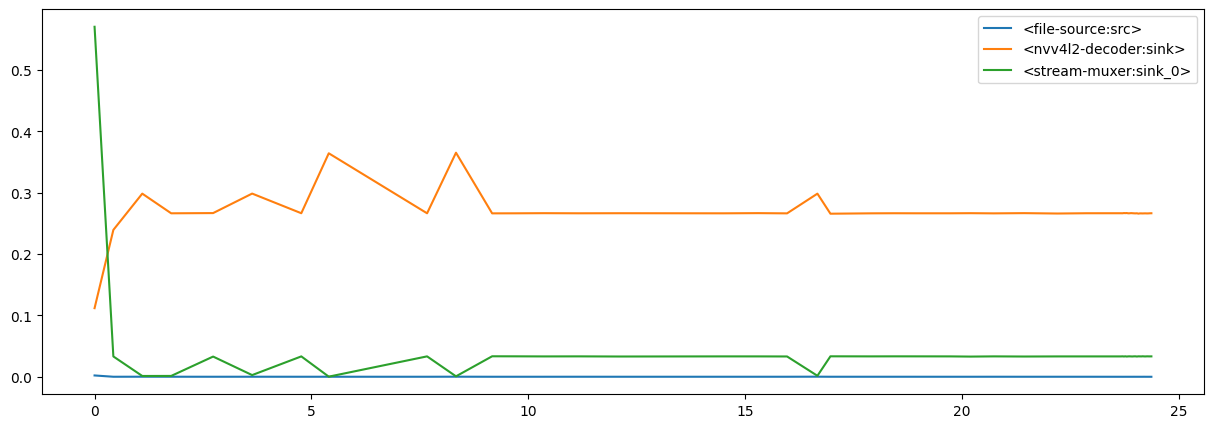

In [ ]:
# Calculate time difference as processed time
diff_df=-time_df.diff(-1).T

# Plot results
diff_df.iloc[:, :-1].plot(figsize=(15, 5)).legend(loc='upper right')

## Viewing the Inference ##
In the next step, we convert the video file into a container file before playing it since the MPEG4 encoded video file can't be played directly in JupyterLab. The [FFmpeg](https://ffmpeg.org/) tool is a very fast video and audio converter with the general syntax: 
* `ffmpeg [global_options] {[input_file_options] -i input_url} ... {[output_file_options] output_url} ...` 

In [ ]:
# Convert MPEG4 video file to MP4 container file
!ffmpeg -i /dli/task/output_04_raw.mpeg4 /dli/task/output_04.mp4 -y -loglevel quiet
from IPython.display import Video
Video("output_04.mp4", width=720)

<video autoplay muted playsinline loop style="width: 100%; height: auto;">
  <source src="../../_static/output_04.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>